# Walk-LCP — demo / test run

This notebook runs the full **walk_lcp** pipeline on a small synthetic DEM,
without requiring any of the manuscript's real data. It is intended as
a smoke test for reviewers and as a worked example for new users.

**What it does:**

1. Builds a 100 × 100 m synthetic DEM with a ridge and a gap.
2. Visualises the surface (hillshade + colour).
3. Runs Dijkstra with Tobler's hiking function from one start point.
4. Shows the cumulative travel-time field.
5. Reconstructs and plots the optimal walking paths to three destinations.
6. Compares each LCP against a naive straight-line "5 km/h on flat ground"
   estimate to show why the cost-surface treatment matters.

**Runtime:** a few seconds on a laptop.

**Dependencies:** numpy, matplotlib, walk_lcp (this repo). The notebook does
not need GDAL, GeoPandas, Shapely, or QGIS — only the pure-math layer is used.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

from walk_lcp import (
    tobler_speed,
    dijkstra_from_start,
    reconstruct_path,
    pixel_to_world,
    world_to_pixel,
    __version__,
)

print(f"walk_lcp version: {__version__}")
print(f"numpy version:    {np.__version__}")


walk_lcp version: 1.0.0
numpy version:    2.4.4


## 1. Build a synthetic DEM

A 100 × 100 grid at 1 m pixel size. A diagonal ridge runs from corner to
corner; a narrow notch ("pass") cuts through it at one point. Start and
stop points sit on opposite sides of the ridge so the algorithm has to
decide whether to climb over or detour through the pass.


In [2]:
nrows, ncols = 100, 100
# GDAL-style affine geotransform: 1 m pixels, origin at (0, 100), Y decreases downward
gt = (0.0, 1.0, 0.0, 100.0, 0.0, -1.0)

yy, xx = np.mgrid[0:nrows, 0:ncols]

# Ridge along the line  row + col = 100  (NW-to-SE diagonal in image space)
ridge = 25.0 * np.exp(-((xx + yy - 100) ** 2) / (2 * 8.0 ** 2))

# A low pass through the ridge at approximately (row=30, col=70)
gap = -18.0 * np.exp(-((xx - 70) ** 2 + (yy - 30) ** 2) / (2 * 6.0 ** 2))

dem = (ridge + gap).astype(np.float32)

print(f"DEM shape:       {dem.shape}")
print(f"Elevation range: {dem.min():.2f} to {dem.max():.2f} m")
print(f"Pixel size:      {gt[1]} m × {abs(gt[5])} m")


DEM shape:       (100, 100)
Elevation range: -0.05 to 25.00 m
Pixel size:      1.0 m × 1.0 m


## 2. Visualise the DEM

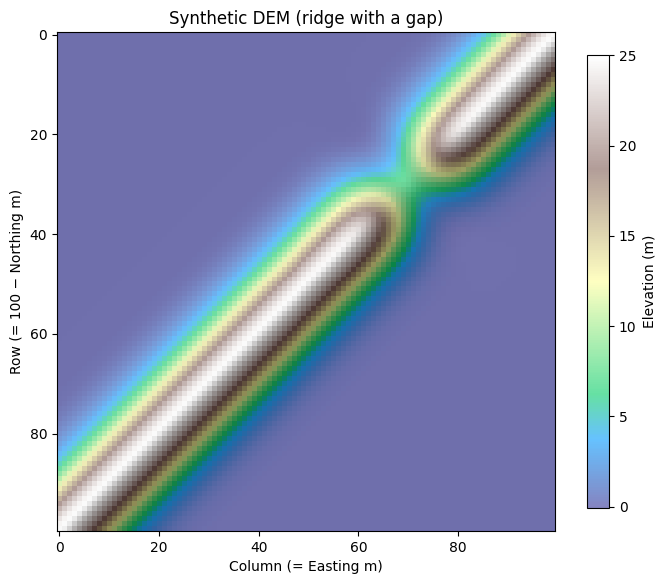

In [3]:
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=1.0, dx=1.0, dy=1.0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(hillshade, cmap='gray')
im = ax.imshow(dem, cmap='terrain', alpha=0.6)
plt.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.85)
ax.set_title('Synthetic DEM (ridge with a gap)')
ax.set_xlabel('Column (= Easting m)')
ax.set_ylabel('Row (= 100 − Northing m)')
plt.tight_layout()
plt.show()


## 3. Define start and stop points

One start point in the lower-left quadrant, three destinations in the
upper-right and at the two opposite corners.


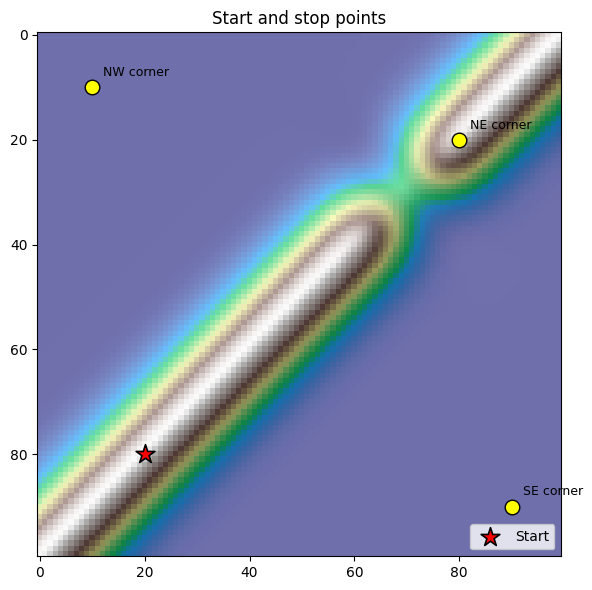

In [4]:
start_rc = (80, 20)
stop_rcs = [(20, 80), (10, 10), (90, 90)]
stop_labels = ['NE corner', 'NW corner', 'SE corner']

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(hillshade, cmap='gray')
ax.imshow(dem, cmap='terrain', alpha=0.6)
sr, sc = start_rc
ax.scatter(sc, sr, c='red', s=200, marker='*', edgecolors='black',
           linewidths=1.2, label='Start', zorder=5)
for (r, c), lbl in zip(stop_rcs, stop_labels):
    ax.scatter(c, r, c='yellow', s=110, marker='o', edgecolors='black',
               linewidths=1.0, zorder=5)
    ax.annotate(lbl, (c, r), textcoords='offset points',
                xytext=(8, 8), fontsize=9)
ax.legend(loc='lower right')
ax.set_title('Start and stop points')
plt.tight_layout()
plt.show()


## 4. Run single-source Dijkstra

Edge cost = `distance / Tobler_speed(slope)`, in seconds. 8-connected
grid graph. Returns a cumulative-time array `cost` and a predecessor
array `prev`.


In [5]:
cost, prev = dijkstra_from_start(dem, gt, start_rc, nodata=None)

print('Cumulative travel time to each destination:')
for (r, c), lbl in zip(stop_rcs, stop_labels):
    t = cost[r, c]
    print(f'  {lbl:12s}  ({r:2d}, {c:2d}):  {t:7.1f} s   =  {t/60:5.2f} min')


Cumulative travel time to each destination:
  NE corner     (20, 80):    363.3 s   =   6.05 min
  NW corner     (10, 10):    240.5 s   =   4.01 min
  SE corner     (90, 90):    240.5 s   =   4.01 min


## 5. Cumulative travel-time field

Each pixel coloured by minutes-from-start. The barrier created by the
ridge is visible as a band of compressed isochrones, and the gap shows
up as a finger of lower cost reaching through it.


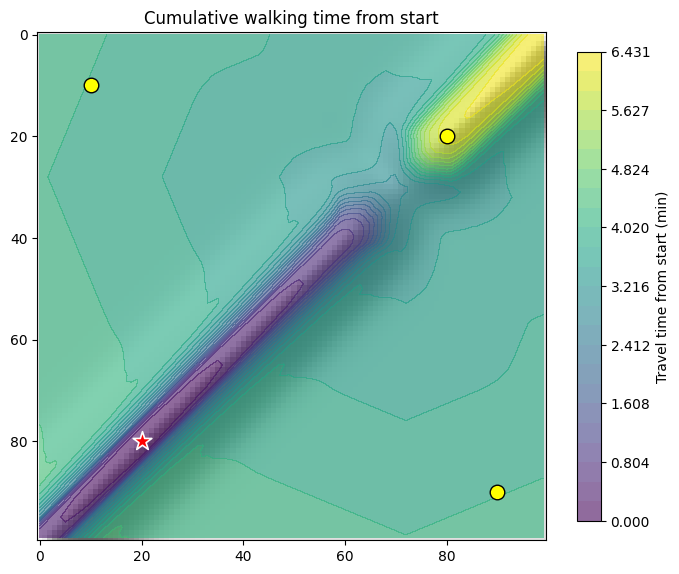

In [6]:
finite = cost[np.isfinite(cost)]
levels = np.linspace(0, finite.max(), 25)

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(hillshade, cmap='gray', alpha=0.6)
cf = ax.contourf(cost / 60.0, levels=levels / 60.0, cmap='viridis', alpha=0.6)
plt.colorbar(cf, ax=ax, label='Travel time from start (min)', shrink=0.85)
ax.scatter(sc, sr, c='red', s=200, marker='*', edgecolors='white',
           linewidths=1.2, zorder=5)
for (r, c) in stop_rcs:
    ax.scatter(c, r, c='yellow', s=110, marker='o', edgecolors='black',
               linewidths=1.0, zorder=5)
ax.set_title('Cumulative walking time from start')
plt.tight_layout()
plt.show()


## 6. Reconstruct and plot the paths

`reconstruct_path` walks the predecessor array backwards from each stop
to the start. The polylines below overlay the actual time-optimal routes.
Notice how the path to the NE corner detours through the gap rather than
climbing the ridge head-on.


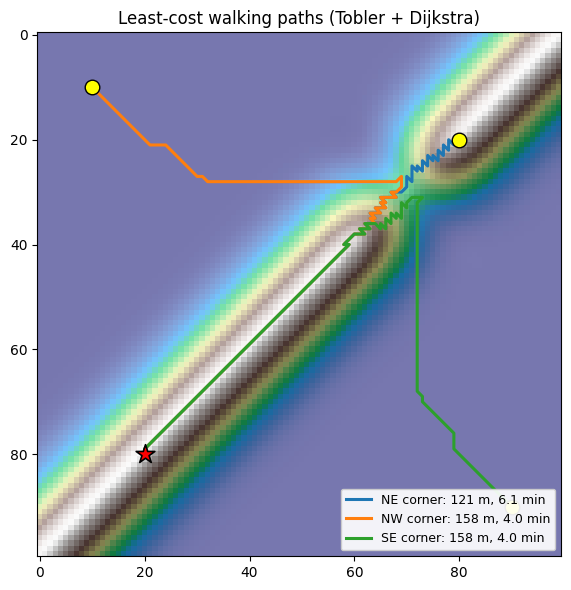

In [7]:
paths = []
for stop_rc in stop_rcs:
    path, dist = reconstruct_path(prev, gt, start_rc, stop_rc)
    paths.append({
        'stop': stop_rc,
        'path': path,
        'dist_m': dist,
        'time_s': float(cost[stop_rc]),
    })

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(hillshade, cmap='gray')
ax.imshow(dem, cmap='terrain', alpha=0.55)
for p, lbl in zip(paths, stop_labels):
    rs, cs = zip(*p['path'])
    ax.plot(cs, rs, lw=2.2,
            label=f"{lbl}: {p['dist_m']:.0f} m, {p['time_s']/60:.1f} min")
ax.scatter(sc, sr, c='red', s=200, marker='*', edgecolors='black',
           linewidths=1.2, zorder=5)
for (r, c) in stop_rcs:
    ax.scatter(c, r, c='yellow', s=110, marker='o', edgecolors='black',
               linewidths=1.0, zorder=5)
ax.legend(loc='lower right', fontsize=9, framealpha=0.92)
ax.set_title('Least-cost walking paths (Tobler + Dijkstra)')
plt.tight_layout()
plt.show()


## 7. LCP vs naive straight-line estimate

A common back-of-envelope estimate is *Euclidean distance ÷ 5 km/h*.
The cost-surface treatment matters when the terrain is rough:


In [8]:
print(f"{'Destination':>12} | {'LCP dist (m)':>13} | {'Straight (m)':>13} | "
      f"{'LCP (min)':>10} | {'Naive (min)':>11} | {'Overhead':>9}")
print('-' * 86)

for p, lbl in zip(paths, stop_labels):
    sr_, sc_ = start_rc
    tr_, tc_ = p['stop']
    eu_m = np.hypot(sr_ - tr_, sc_ - tc_)
    naive_min = eu_m / (5000 / 60.0)       # 5 km/h in m/min
    lcp_min = p['time_s'] / 60.0
    overhead = (lcp_min / naive_min - 1) * 100
    print(f"{lbl:>12} | {p['dist_m']:>13.1f} | {eu_m:>13.1f} | "
          f"{lcp_min:>10.2f} | {naive_min:>11.2f} | {overhead:>+8.1f}%")


 Destination |  LCP dist (m) |  Straight (m) |  LCP (min) | Naive (min) |  Overhead
--------------------------------------------------------------------------------------
   NE corner |         121.4 |          84.9 |       6.05 |        1.02 |   +494.6%
   NW corner |         157.6 |          70.7 |       4.01 |        0.85 |   +372.3%
   SE corner |         157.6 |          70.7 |       4.01 |        0.85 |   +372.3%


## 8. Sanity check: Tobler's hiking function

A quick sanity plot of the cost model. The function peaks at S = −0.05
(5 % downhill); both steeper uphills and steeper downhills slow the
walker down sharply.


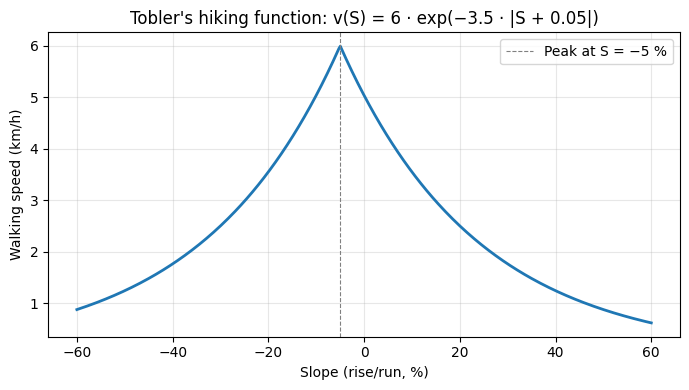

In [9]:
slopes = np.linspace(-0.6, 0.6, 400)
speeds_kmh = np.array([tobler_speed(s) * 3.6 for s in slopes])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(slopes * 100, speeds_kmh, lw=2)
ax.axvline(-5, color='gray', ls='--', lw=0.8, label='Peak at S = −5 %')
ax.set_xlabel('Slope (rise/run, %)')
ax.set_ylabel('Walking speed (km/h)')
ax.set_title("Tobler's hiking function: v(S) = 6 · exp(−3.5 · |S + 0.05|)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 9. Summary

This notebook exercised the full pipeline:

- Tobler's hiking function over a wide slope range — function returns
  finite, monotonic values around its peak at S = −5 %.
- Dijkstra on an 8-connected grid — every cell reachable on a connected
  DEM has a finite cost, and the algorithm correctly detours around the
  ridge to use the gap.
- Path reconstruction — the polylines closed back to the start point.

A reviewer can re-run this notebook to confirm the algorithm produces
the same results on their machine. To reproduce the manuscript's results
on real data, see the CLI section of `README.md`.
